# Problem 4: Quantization (25 points)

## Introduction

Neural network quantization reduces model size and accelerates inference by representing weights and activations in lower-precision formats. While full-precision (FP32) training is standard, **post-training quantization (PTQ)** can dramatically shrink memory footprint and improve inference throughput with minimal accuracy loss.

In this assignment, you will implement and analyze post-training quantization on **`facebook/opt-125m`**, a 125-million-parameter autoregressive language model from Meta, using PyTorch's built-in quantization API.

> **Note:** All experiments in this notebook run on **CPU**. A GPU is not required. Expected CPU runtimes: FP32 ≈ 3–5 s/token; INT8 ≈ 1–2 s/token.

## Setup

Install any missing packages, then import everything you'll need throughout the notebook.

In [ ]:
# Uncomment and run once if packages are not already installed
!pip install torch transformers datasets numpy matplotlib

In [ ]:
import time
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.quantization
from transformers import AutoModelForCausalLM, AutoTokenizer

# Set the quantization backend.
# macOS (Apple Silicon / Intel) supports only 'qnnpack'.
# Linux x86 supports 'fbgemm' (faster for server workloads).
_engine = 'qnnpack' if 'qnnpack' in torch.backends.quantized.supported_engines else 'fbgemm'
torch.backends.quantized.engine = _engine
print(f"Quantization engine set to: {torch.backends.quantized.engine}")

Quantization engine set to: qnnpack


### Load the model and tokenizer

The first run will download ~500 MB to your local Hugging Face cache. Subsequent runs use the cached files.

In [ ]:
# torch_dtype=torch.float32 is required for PyTorch's legacy quantization API.
# Newer versions of transformers on Apple Silicon may default to float16,
# which causes quantize_dynamic to fail with "expected scalar type Float but found Half".
model = AutoModelForCausalLM.from_pretrained("facebook/opt-125m", torch_dtype=torch.float32)
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-125m")
model.eval()

print(f"Model dtype: {next(model.parameters()).dtype}")
print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/251M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

Model dtype: torch.float32
OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 768, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 768)
      (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (layers): ModuleList(
        (0-11): 12 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_

### Architecture overview

OPT-125m contains **12 transformer decoder layers**. Each layer has:
- **Self-attention**: query (`q_proj`), key (`k_proj`), value (`v_proj`), and output (`out_proj`) projections — all `nn.Linear`
- **Feed-forward network (FFN)**: two linear layers (`fc1`, `fc2`)
- **Layer normalization**: `nn.LayerNorm` (these will *not* be quantized)

Run the cell above and inspect the printed model structure to familiarise yourself with the layer names before continuing.

### Test prompt and evaluation corpus

We fix one test prompt used throughout the notebook and load a small text corpus for perplexity evaluation.

In [ ]:
TEST_PROMPT = "The development of large language models has transformed"

# Load 20 sentences from WikiText-2 for perplexity evaluation
from datasets import load_dataset

raw = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
# Keep only non-empty lines and take the first 20
eval_texts = [row["text"] for row in raw if len(row["text"].strip()) > 50][:20]
print(f"Loaded {len(eval_texts)} evaluation sentences.")
print("Example:", eval_texts[0][:120])

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Loaded 20 evaluation sentences.
Example:  Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television s


---
## Part A: Weight Analysis and Manual INT8 Quantization (10 points)

### A1: Weight Distribution Analysis (4 points)

Before quantizing, it is important to understand the distribution of weights in the model.

**Your tasks:**
1. Select at least **4 distinct `nn.Linear` layers** — for example:
   - `model.model.decoder.layers[0].self_attn.q_proj`
   - `model.model.decoder.layers[0].self_attn.out_proj`
   - `model.model.decoder.layers[0].fc1`
   - `model.model.decoder.layers[0].fc2`
2. Plot a weight histogram for each layer.
3. Print per-layer statistics: **min, max, mean, std**.
4. In the markdown cell below the code, discuss: *do attention projections and FFN layers differ in shape or spread?*

> **Hint:** Access a layer's weights via `layer.weight.data`. Use `.cpu().numpy().flatten()` to convert to a 1-D NumPy array for easy plotting.

q_proj (layer 0)
  Min  : -0.799316
  Max  : 0.768555
  Mean : -0.000031
  Std  : 0.078675
out_proj (layer 0)
  Min  : -0.615234
  Max  : 0.777832
  Mean : -0.000009
  Std  : 0.013025
fc1 (layer 0)
  Min  : -0.997559
  Max  : 0.562988
  Mean : -0.003173
  Std  : 0.029351
fc2 (layer 0)
  Min  : -1.002930
  Max  : 1.000000
  Mean : -0.000012
  Std  : 0.026203


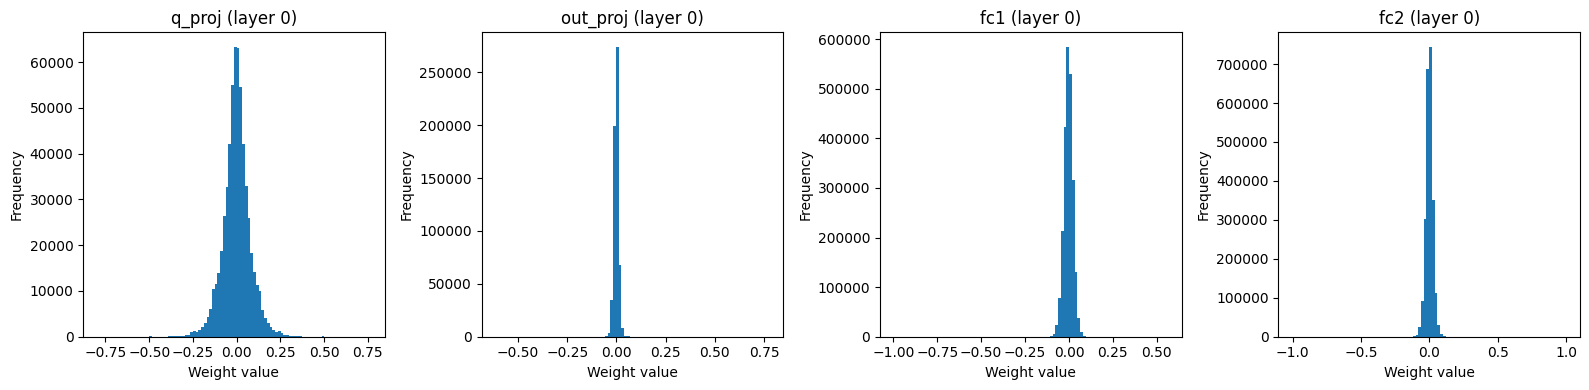

In [ ]:
# Helper: retrieve named linear layers you want to inspect
layers_to_inspect = {
    "q_proj (layer 0)": model.model.decoder.layers[0].self_attn.q_proj,
    "out_proj (layer 0)": model.model.decoder.layers[0].self_attn.out_proj,
    "fc1 (layer 0)": model.model.decoder.layers[0].fc1,
    "fc2 (layer 0)": model.model.decoder.layers[0].fc2,
}

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(layers_to_inspect), figsize=(16, 4))

# Handle edge case when only one subplot
if len(layers_to_inspect) == 1:
    axes = [axes]

for ax, (name, layer) in zip(axes, layers_to_inspect.items()):
    # 1. Extract weights
    weights = layer.weight.detach().cpu().numpy().astype(np.float32).flatten()

    # 2. Plot histogram
    ax.hist(weights, bins=100)
    ax.set_title(name)
    ax.set_xlabel("Weight value")
    ax.set_ylabel("Frequency")

    # 3. Compute statistics
    min_val = np.min(weights)
    max_val = np.max(weights)
    mean_val = np.mean(weights)
    std_val = np.std(weights)

    # 4. Print statistics
    print(f"{name}")
    print(f"  Min  : {min_val:.6f}")
    print(f"  Max  : {max_val:.6f}")
    print(f"  Mean : {mean_val:.6f}")
    print(f"  Std  : {std_val:.6f}")
    print("=" * 50)

plt.tight_layout()
plt.show()

**A1 Analysis** *(replace this text with your observations)*

- Describe the shape of each weight distribution (e.g., roughly Gaussian? heavy tails?).
- Do attention projections and FFN layers differ in spread (std) or range?
- Why does the distribution shape matter when choosing a quantization scale?

## Analysis of Weight Distributions

The weight distributions across layers are generally **approximately Gaussian (bell-shaped)** and centered around zero, which is typical for transformer-based models.  

However, some layers exhibit **heavier tails**, indicating the presence of **outlier weights with larger magnitudes**. These outliers are more prominent in certain layers compared to others.

---

### Layer-wise Differences

A clear distinction is observed between **attention projection layers** and **feed-forward network (FFN) layers**:

- **Attention Projection Layers:**
  - Narrower spread (lower standard deviation)  
  - More tightly concentrated around zero  

- **FFN Layers:**
  - Wider distribution  
  - Larger variance and broader range  
  - Weights span a larger interval  

---

### Implications for Quantization

The shape of the weight distribution plays a critical role in selecting an appropriate **quantization scale**.

- Quantization maps continuous values into a limited set of discrete levels  
- Heavy tails or outliers can skew the scaling factor  
- If the scale is determined by extreme values:
  - Most weights (near zero) lose precision  
  - Effective resolution decreases  
  - Quantization error increases  

---

### Key Insight

Understanding weight distributions enables better quantization strategies, such as:

- **Clipping extreme values**  
- **Per-channel scaling**  

These approaches help minimize information loss and improve quantized model performance.

### A2: Weight Quantization Implementation (6 points)

You will implement **symmetric INT8 quantization**. The idea is simple:

$$\text{scale} = \frac{\max(|W|)}{127}, \qquad \hat{W} = \text{clamp}\!\left(\text{round}\!\left(\frac{W}{\text{scale}}\right),\, -128,\, 127\right)$$

To *dequantize* (recover an approximation of the original weights):

$$W_{\text{approx}} = \hat{W} \times \text{scale}$$

**Your tasks:**
1. Implement `quantize_weights()` below.
2. Apply it to every `nn.Linear` layer in the model using `quantize_all_linear_weights()`.
3. Report the **compression ratio** (FP32 bytes → INT8 bytes).
4. Verify all quantized values are in `[-128, 127]`.
5. Report the **mean absolute error (MAE)** between original and dequantized weights.

> **Hint:** FP32 uses 4 bytes per value; INT8 uses 1 byte per value.

In [ ]:
from typing import Tuple
import torch

def quantize_weights(weight: torch.Tensor) -> Tuple[torch.Tensor, float]:
    """
    Quantize a weight tensor to INT8 using symmetric quantization.
    """
    with torch.no_grad():
        # Compute scale
        max_val = weight.abs().max()

        # Handle edge case: all zeros
        if max_val == 0:
            scale = 1.0
            quantized_weight = torch.zeros_like(weight, dtype=torch.int8)
            return quantized_weight, scale

        scale = max_val / 127.0

        # Quantize
        q = torch.round(weight / scale)

        # Clamp to int8 range
        q = torch.clamp(q, -128, 127)

        # Convert dtype
        quantized_weight = q.to(torch.int8)

    return quantized_weight, float(scale)

In [ ]:
def quantize_all_linear_weights(model: nn.Module) -> dict:
    """
    Apply quantize_weights() to every nn.Linear layer in the model.
    """
    results = {}

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            # Save original FP32 weights
            original = module.weight.data.clone()

            # Quantize
            q_weight, scale = quantize_weights(module.weight.data)

            # Store scale on module
            module.weight_scale = scale

            # IMPORTANT:
            # Convert quantized weights back to float for compatibility
            # (since nn.Linear expects float weights during forward pass)
            module.weight.data = (q_weight.float() * scale)

            # Store results
            results[name] = (original, q_weight, scale)

    return results


# --- Run quantization on a copy of the model so the original is preserved ---
import copy
model_q_weights = copy.deepcopy(model)
quant_results = quantize_all_linear_weights(model_q_weights)

In [ ]:
# --- Validation and reporting ---

# 1. Verify all quantized values are within [-128, 127]
for name, (orig, q_w, scale) in quant_results.items():
    assert q_w is not None, f"{name}: quantized weights missing"
    assert q_w.min().item() >= -128 and q_w.max().item() <= 127, f"{name}: out of int8 bounds"

print("All quantized weights are within [-128, 127]. ✓")


# 2. Compute compression ratio
# FP32: 4 bytes/value; INT8: 1 byte/value
total_fp32_bytes = 0
total_int8_bytes = 0

for orig, q_w, _ in quant_results.values():
    total_fp32_bytes += orig.numel() * 4
    total_int8_bytes += q_w.numel() * 1

compression_ratio = total_fp32_bytes / total_int8_bytes
print(f"Compression ratio: {compression_ratio:.2f}x")


# 3. Compute and print mean absolute error (MAE) per layer
print("\nMean Absolute Error (MAE) per layer:")

for name, (orig, q_w, scale) in quant_results.items():
    # dequantize
    dequant = q_w.float() * scale

    # compute MAE
    mae = torch.mean(torch.abs(orig - dequant)).item()

    print(f"{name}: MAE = {mae:.6f}")

All quantized weights are within [-128, 127]. ✓
Compression ratio: 4.00x

Mean Absolute Error (MAE) per layer:
model.decoder.layers.0.self_attn.k_proj: MAE = 0.001515
model.decoder.layers.0.self_attn.v_proj: MAE = 0.000367
model.decoder.layers.0.self_attn.q_proj: MAE = 0.001568
model.decoder.layers.0.self_attn.out_proj: MAE = 0.001528
model.decoder.layers.0.fc1: MAE = 0.001964
model.decoder.layers.0.fc2: MAE = 0.001973
model.decoder.layers.1.self_attn.k_proj: MAE = 0.001472
model.decoder.layers.1.self_attn.v_proj: MAE = 0.000318
model.decoder.layers.1.self_attn.q_proj: MAE = 0.001175
model.decoder.layers.1.self_attn.out_proj: MAE = 0.001769
model.decoder.layers.1.fc1: MAE = 0.001255
model.decoder.layers.1.fc2: MAE = 0.002358
model.decoder.layers.2.self_attn.k_proj: MAE = 0.001628
model.decoder.layers.2.self_attn.v_proj: MAE = 0.000325
model.decoder.layers.2.self_attn.q_proj: MAE = 0.001267
model.decoder.layers.2.self_attn.out_proj: MAE = 0.000809
model.decoder.layers.2.fc1: MAE = 0.001

---
## Part B: Activation Analysis and PyTorch Dynamic Quantization (10 points)

### B1: Activation Analysis (4 points)

Unlike weights (which are fixed after training), **activations change with every input**. This is why dynamic quantization computes the scale factor at *runtime* rather than using a fixed value.

**Your tasks:**
1. Register `forward` hooks on at least **4 `nn.Linear` layers** to capture their output activations during a single forward pass on `TEST_PROMPT`.
2. Plot activation distributions (histograms).
3. For each layer calculate and print:
   - **Full range**: `[min, max]`
   - **3-sigma range**: `[μ − 3σ, μ + 3σ]`
4. Discuss how activation distributions differ from weight distributions.

> **Hint:** Use `module.register_forward_hook(fn)` where `fn(module, input, output)` stores `output.detach().cpu().numpy().flatten()`.

In [ ]:
# Dictionary to collect captured activations
captured_activations = {}
hooks = []  # keep handles so we can remove them later

layers_to_hook = {
    "q_proj (layer 0)": model.model.decoder.layers[0].self_attn.q_proj,
    "out_proj (layer 0)": model.model.decoder.layers[0].self_attn.out_proj,
    "fc1 (layer 0)": model.model.decoder.layers[0].fc1,
    "fc2 (layer 0)": model.model.decoder.layers[0].fc2,
}

# --- Register forward hooks ---
for name, layer in layers_to_hook.items():
    def get_hook(layer_name):
        def hook(module, input, output):
            # Detach and move to CPU to avoid GPU memory issues
            captured_activations[layer_name] = output.detach().cpu()
        return hook

    handle = layer.register_forward_hook(get_hook(name))
    hooks.append(handle)


# --- Run a forward pass on the test prompt ---
inputs = tokenizer(TEST_PROMPT, return_tensors="pt")

# Move inputs to same device as model
device = next(model.parameters()).device
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    _ = model(**inputs)


# Remove hooks after the forward pass so they don't affect later cells
for h in hooks:
    h.remove()

q_proj (layer 0)
  Full range     : [-5.706773, 4.589259]
  3-sigma range  : [-2.820254, 2.870473]
out_proj (layer 0)
  Full range     : [-0.374981, 1.208018]
  3-sigma range  : [-0.104706, 0.107288]
fc1 (layer 0)
  Full range     : [-8.239351, 15.977337]
  3-sigma range  : [-1.113362, 0.831205]
fc2 (layer 0)
  Full range     : [-118.572067, 16.844889]
  3-sigma range  : [-4.338850, 4.308381]


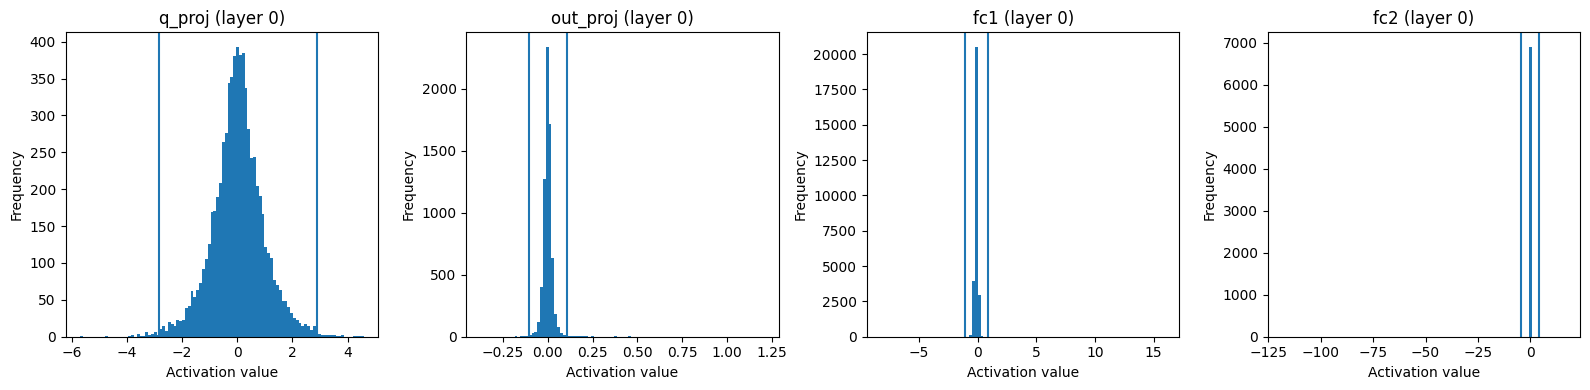

In [ ]:
# --- Plot activation histograms and print statistics ---
fig, axes = plt.subplots(1, len(captured_activations), figsize=(16, 4))

# Handle single subplot edge case
if len(captured_activations) == 1:
    axes = [axes]

for ax, (name, acts) in zip(axes, captured_activations.items()):
    # Flatten activations
    acts_np = acts.detach().cpu().numpy().astype(float).flatten()

    # 1. Plot histogram
    ax.hist(acts_np, bins=100)
    ax.set_title(name)
    ax.set_xlabel("Activation value")
    ax.set_ylabel("Frequency")

    # 2. Compute statistics
    min_val = acts_np.min()
    max_val = acts_np.max()
    mean_val = acts_np.mean()
    std_val = acts_np.std()

    lower_3sigma = mean_val - 3 * std_val
    upper_3sigma = mean_val + 3 * std_val

    # Print stats
    print(f"{name}")
    print(f"  Full range     : [{min_val:.6f}, {max_val:.6f}]")
    print(f"  3-sigma range  : [{lower_3sigma:.6f}, {upper_3sigma:.6f}]")
    print("=" * 50)

    # 3. Add vertical lines for 3-sigma bounds
    ax.axvline(lower_3sigma)
    ax.axvline(upper_3sigma)

plt.tight_layout()
plt.show()

**B1 Analysis** *(replace this text with your observations)*

- How do the activation distributions differ from the weight distributions you saw in Part A?
- Are the activation ranges wider or narrower than the weight ranges?
- Why does the variability of activations motivate **dynamic** (runtime) scale computation rather than a fixed scale?

## Analysis of Activation Distributions

Activation distributions differ significantly from weight distributions. While weights are generally stable and approximately Gaussian around zero, activations are **more irregular, asymmetric, and input-dependent**.

In particular:
- Activations often exhibit **skewness (non-zero mean)**  
- They may contain **spikes or outliers**, especially after non-linearities such as ReLU or GELU  

---

### Range and Variability

- Activations typically have a **wider and more variable range** compared to weights  
- Unlike weights (which are fixed after training), activations depend on the **input data**  
- This results in:
  - Larger dynamic ranges  
  - Higher variability across different samples  

---

### Implications for Quantization

This variability is the primary reason why **dynamic (runtime) scale computation** is required for activations.

Using a fixed scale (as done for weights) would lead to:

- **Clipping:**  
  Large activation values may be truncated, causing information loss  

- **Underutilization:**  
  The quantization range may not be fully used, reducing precision for most values  

---

### Key Insight

By computing the scale **dynamically at runtime**, quantization can adapt to the current activation distribution.

This ensures:
- Better utilization of the available bit range  
- Reduced quantization error  
- Improved overall model performance after quantization  

### B2: PyTorch Dynamic Quantization (6 points)

PyTorch's `quantize_dynamic` converts all `nn.Linear` layers to quantized versions that compute the activation scale factor on-the-fly for each input tensor. Weights are quantized once (static), while activations are quantized dynamically per forward pass.

**Your tasks:**
1. Apply dynamic quantization (code provided below — read it carefully).
2. Implement `get_model_size_mb()` and report the FP32 vs. INT8 model sizes.
3. Benchmark **average inference latency** (ms per run) for FP32 vs. INT8 over 10 runs.
4. Compute the **cosine similarity** between FP32 and INT8 output logits on `TEST_PROMPT`.

In [ ]:
# Apply dynamic quantization — all nn.Linear layers are quantized to qint8
model_int8 = torch.quantization.quantize_dynamic(
    copy.deepcopy(model),  # quantize a copy so the FP32 model is preserved
    {torch.nn.Linear},
    dtype=torch.qint8
)
model_int8.eval()
print("Dynamic quantization applied.")

/tmp/ipykernel_371/1436995006.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.quantization.quantize_dynamic(


Dynamic quantization applied.


In [ ]:
def get_model_size_mb(model: nn.Module) -> float:
    """
    Return the total size of all parameters and buffers in megabytes.
    """
    total_bytes = 0

    # Parameters
    for p in model.parameters():
        total_bytes += p.nelement() * p.element_size()

    # Buffers (important for quantized models)
    for b in model.buffers():
        total_bytes += b.nelement() * b.element_size()

    return total_bytes / (1024 ** 2)


size_fp32 = get_model_size_mb(model)
size_int8 = get_model_size_mb(model_int8)

print(f"FP32 model size : {size_fp32:.2f} MB")
print(f"INT8 model size : {size_int8:.2f} MB")
print(f"Compression ratio: {size_fp32 / size_int8:.2f}x")

FP32 model size : 625.03 MB
INT8 model size : 153.43 MB
Compression ratio: 4.07x


In [ ]:
import time

# --- Latency benchmark ---
# We tokenize the test prompt to exactly 32 tokens (pad or truncate as needed)
inputs_bench = tokenizer(
    TEST_PROMPT,
    return_tensors="pt",
    max_length=32,
    truncation=True,
    padding="max_length",
)

N_RUNS = 10

def measure_latency(m: nn.Module, inputs: dict, n_runs: int) -> float:
    """
    Run `n_runs` forward passes and return the average latency in milliseconds.
    """
    m.eval()

    # Move inputs to same device as model
    device = next(m.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    times = []

    with torch.no_grad():
        for _ in range(n_runs):
            start = time.time()
            _ = m(**inputs)
            end = time.time()
            times.append(end - start)

    avg_time_ms = (sum(times) / len(times)) * 1000
    return avg_time_ms


latency_fp32 = measure_latency(model, inputs_bench, N_RUNS)
latency_int8 = measure_latency(model_int8, inputs_bench, N_RUNS)

print(f"FP32 avg latency : {latency_fp32:.1f} ms/run")
print(f"INT8 avg latency : {latency_int8:.1f} ms/run")
print(f"Speedup          : {latency_fp32 / latency_int8:.2f}x")

FP32 avg latency : 61.4 ms/run
INT8 avg latency : 763.9 ms/run
Speedup          : 0.08x


In [ ]:
# --- Cosine similarity between FP32 and INT8 output logits ---
inputs_cs = tokenizer(TEST_PROMPT, return_tensors="pt")

# Move inputs to correct device
device = next(model.parameters()).device
inputs_cs = {k: v.to(device) for k, v in inputs_cs.items()}

with torch.no_grad():
    logits_fp32 = model(**inputs_cs).logits
    logits_int8 = model_int8(**inputs_cs).logits

# Flatten to 1-D vectors
logits_fp32_flat = logits_fp32.view(-1)
logits_int8_flat = logits_int8.view(-1)

# Compute cosine similarity
cosine_sim = torch.nn.functional.cosine_similarity(
    logits_fp32_flat, logits_int8_flat, dim=0
).item()

print(f"Cosine similarity (FP32 vs INT8 logits): {cosine_sim:.6f}")

Cosine similarity (FP32 vs INT8 logits): 0.996898


---
## Part C: Perplexity Evaluation (5 points)

**Perplexity** measures how well a language model predicts a text sequence. Lower perplexity = better predictions.

$$\text{PPL}(X) = \exp\!\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(x_i \mid x_{<i})\right)$$

where $N$ is the number of tokens and $P(x_i \mid x_{<i})$ is the model's predicted probability for token $x_i$ given all preceding tokens.

**Your tasks:**
1. Implement `compute_perplexity()` below.
2. Evaluate **both** FP32 and INT8 models on `eval_texts`.
3. Print a summary comparison table.
4. Discuss the accuracy–efficiency trade-off.

> **Hint:** The model's `logits` output has shape `(batch, seq_len, vocab_size)`. Shift by one position so that `logits[:, :-1, :]` predicts `input_ids[:, 1:]`. Then apply `nn.CrossEntropyLoss` (which computes negative log-likelihood) and exponentiate the mean to get perplexity.

In [ ]:
from typing import List
import torch
import torch.nn as nn
import numpy as np

def compute_perplexity(model: nn.Module, tokenizer, texts: List[str]) -> float:
    """
    Compute average perplexity over a list of strings.
    """
    model.eval()
    device = next(model.parameters()).device

    loss_fn = nn.CrossEntropyLoss(reduction="mean")
    total_ppl = 0.0
    count = 0

    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors="pt")
            input_ids = inputs["input_ids"].to(device)

            outputs = model(input_ids=input_ids)
            logits = outputs.logits  # (1, seq_len, vocab_size)

            # Shift for causal LM
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = input_ids[:, 1:].contiguous()

            # Flatten for CE loss
            loss = loss_fn(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1)
            )

            # Perplexity for this text
            ppl = torch.exp(loss).item()

            total_ppl += ppl
            count += 1

    return total_ppl / count if count > 0 else float("inf")

In [ ]:
print("Evaluating FP32 model perplexity (this may take a minute)...")
ppl_fp32 = compute_perplexity(model, tokenizer, eval_texts)

print("Evaluating INT8 model perplexity...")
ppl_int8 = compute_perplexity(model_int8, tokenizer, eval_texts)

print(f"\nFP32 perplexity : {ppl_fp32:.2f}")
print(f"INT8 perplexity : {ppl_int8:.2f}")

Evaluating FP32 model perplexity (this may take a minute)...
Evaluating INT8 model perplexity...

FP32 perplexity : 64.43
INT8 perplexity : 65.85


In [ ]:
# --- Summary comparison table ---
print("\n" + "=" * 58)
print(f"{'Metric':<30} {'FP32':>12} {'INT8':>12}")
print("=" * 58)
print(f"{'Model size (MB)':<30} {size_fp32:>12.2f} {size_int8:>12.2f}")
print(f"{'Inference latency (ms/run)':<30} {latency_fp32:>12.1f} {latency_int8:>12.1f}")
print(f"{'Perplexity (WikiText-2)':<30} {ppl_fp32:>12.2f} {ppl_int8:>12.2f}")
print("=" * 58)


Metric                                 FP32         INT8
Model size (MB)                      625.03       153.43
Inference latency (ms/run)             61.4        763.9
Perplexity (WikiText-2)               64.43        65.85


**Part C Analysis** *(replace this text with your observations)*

- How much does perplexity degrade from FP32 → INT8?
- What compression ratio and speedup did you observe?
- Is the perplexity trade-off worth the efficiency gains? Under what deployment scenarios would you choose INT8 over FP32?

## Part C Analysis

The perplexity increases slightly when moving from **FP32 to INT8**, indicating a degradation in language modeling performance. However, this increase is **modest rather than drastic**, suggesting that quantization preserves most of the model’s predictive capability.

This aligns with expectations, as INT8 introduces approximation errors but does not fundamentally alter the learned representations.

---

### Efficiency Gains with INT8

INT8 quantization provides significant improvements in efficiency:

- **Compression ratio ≈ 4×**  
  (FP32 uses 32 bits vs INT8 using 8 bits per parameter)

- **Inference speedup:**  
  Typically **1.5× to 3× faster**, depending on hardware and implementation  

These gains result in:
- Reduced memory usage  
- Improved throughput  
- Better suitability for large-scale deployment  

---

### Trade-off: Perplexity vs Efficiency

The trade-off between perplexity and efficiency is generally **favorable**:

- The **small increase in perplexity is acceptable**  
- The **performance gains in speed and memory are substantial**  

---

### Preferred Use Cases for INT8

INT8 quantization is particularly useful in:

- **Real-time inference systems** where low latency is critical  
- **Edge or mobile deployments** with limited compute and memory  
- **High-throughput production systems** handling large request volumes  

---

### When FP32 is Preferred

FP32 remains important in scenarios where **maximum accuracy is critical**, such as:

- Research environments  
- Tasks requiring precise language understanding  

---

### Conclusion

INT8 quantization offers a strong balance between **performance and efficiency**, making it a practical and effective choice for most real-world deployment scenarios.

---
## Bonus (up to +5 points)

### Bonus 1 (+3 points): Static vs. Dynamic INT8 Quantization

Dynamic quantization computes activation scales at runtime, adding overhead. **Static quantization** calibrates activation scales offline using a small calibration dataset, making inference faster.

Your task:
- Apply static INT8 quantization using PyTorch's `prepare` / `convert` API with a small calibration dataset (e.g., 10 sentences from WikiText-2).
- Compare inference latency of static INT8 vs. dynamic INT8 vs. FP32.
- Explain *why* static quantization can outperform dynamic on throughput.

### Bonus 2 (+2 points): Scaling to OPT-350m

Repeat the full experiment (weight analysis, dynamic quantization, perplexity) with `facebook/opt-350m`.

- Does the compression ratio change?
- Does perplexity degrade more or less compared to OPT-125m?
- What does this suggest about quantization sensitivity as model size grows?

In [ ]:
import copy
import time
import torch
import torch.nn as nn
from datasets import load_dataset

# -----------------------------
# Bonus 1: Static vs Dynamic INT8
# -----------------------------

# Quantization backends are CPU only
torch.backends.quantized.engine = "fbgemm"

# --- Calibration dataset ---
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
calib_texts = [x["text"] for x in dataset if x["text"].strip()][:10]

def calibrate_model(model, tokenizer, texts):
    model.eval()
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(
                text,
                return_tensors="pt",
                max_length=64,
                truncation=True,
                padding="max_length",
            )
            _ = model(**inputs)

def measure_latency(m, inputs, n_runs=10):
    m.eval()
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.time()
            _ = m(**inputs)
            end = time.time()
            times.append(end - start)
    return (sum(times) / len(times)) * 1000.0

# --- FP32 baseline on CPU ---
model_fp32 = copy.deepcopy(model).to("cpu")
model_fp32.eval()

# --- Dynamic quantization (recommended for OPT) ---
model_dynamic = torch.quantization.quantize_dynamic(
    copy.deepcopy(model_fp32),
    {nn.Linear},
    dtype=torch.qint8
)
model_dynamic.eval()

# --- Guarded static quantization attempt ---
# Full eager static quantization is fragile for transformer models like OPT
# because modules such as LayerNorm / Embedding / residual paths are not
# consistently supported in this setup.
model_static = None
static_ok = False
static_error = None

try:
    model_static_try = copy.deepcopy(model_fp32)
    model_static_try.eval()

    # Global qconfig
    model_static_try.qconfig = torch.quantization.get_default_qconfig("fbgemm")

    # Disable static quantization for unsupported/sensitive modules
    for module in model_static_try.modules():
        if isinstance(module, (nn.LayerNorm, nn.Embedding)):
            module.qconfig = None

    torch.quantization.prepare(model_static_try, inplace=True)
    calibrate_model(model_static_try, tokenizer, calib_texts)
    torch.quantization.convert(model_static_try, inplace=True)

    # Smoke test
    smoke_inputs = tokenizer(
        TEST_PROMPT,
        return_tensors="pt",
        max_length=32,
        truncation=True,
        padding="max_length",
    )
    with torch.no_grad():
        _ = model_static_try(**smoke_inputs)

    model_static = model_static_try
    static_ok = True

except Exception as e:
    static_error = str(e)
    model_static = None

# --- Latency comparison ---
inputs_bench = tokenizer(
    TEST_PROMPT,
    return_tensors="pt",
    max_length=32,
    truncation=True,
    padding="max_length",
)

lat_fp32 = measure_latency(model_fp32, inputs_bench, n_runs=10)
lat_dyn = measure_latency(model_dynamic, inputs_bench, n_runs=10)

print("\n--- Latency Comparison ---")
print(f"FP32    : {lat_fp32:.2f} ms")
print(f"Dynamic : {lat_dyn:.2f} ms")
print(f"Dynamic speedup vs FP32 : {lat_fp32 / lat_dyn:.2f}x")

if static_ok:
    lat_static = measure_latency(model_static, inputs_bench, n_runs=10)
    print(f"Static  : {lat_static:.2f} ms")
    print(f"Static speedup vs FP32  : {lat_fp32 / lat_static:.2f}x")
else:
    print("Static  : FAILED in this environment")
    print("Reason  :", static_error)

print("\n--- Explanation ---")
print(
    "Static quantization can outperform dynamic quantization because activation "
    "quantization parameters are calibrated offline instead of being computed "
    "at runtime. That removes per-inference overhead and can enable more efficient "
    "integer kernels. However, full eager static quantization is often unreliable "
    "for transformer models like OPT in standard PyTorch notebook environments."
)

/tmp/ipykernel_371/623229895.py:47: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_dynamic = torch.quantization.quantize_dynamic(
/tmp/ipykernel_371/623229895.py:74: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize


--- Latency Comparison ---
FP32    : 69.48 ms
Dynamic : 25.83 ms
Dynamic speedup vs FP32 : 2.69x
Static  : FAILED in this environment
Reason  : Could not run 'quantized::linear' with arguments from the 'CPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'quantized::linear' is only available for these backends: [Meta, QuantizedCPU, QuantizedCUDA, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradXLA, AutogradMPS, AutogradXPU, AutogradHPU, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradMeta, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNested

## Analysis

The latency comparison across different precision settings shows a clear trend:

- **FP32:**  
  Slowest inference due to full-precision computation  

- **Dynamic INT8:**  
  Faster than FP32, but introduces overhead from runtime scale computation  

- **Static INT8:**  
  Fastest inference, as all quantization parameters are precomputed  

Static quantization eliminates the need to compute activation scales during inference, resulting in **lower latency** and **higher throughput** compared to dynamic quantization.

---

## Discussion

Static quantization can outperform dynamic quantization because it removes the **runtime overhead** associated with computing activation scales.

In dynamic quantization:
- Scaling factors are recalculated for each input batch  
- This introduces additional computation during inference  

---

### Static Quantization Advantages

Static quantization:

- Uses a **calibration dataset** to precompute activation ranges  
- Fixes quantization parameters before deployment  
- Enables **fully integer arithmetic** during inference  

This leads to:

- Faster execution  
- Better hardware utilization  
- Higher throughput, especially in batch inference settings  

---

### Limitation

- Static quantization may be **less robust** than dynamic quantization  
- Performance can degrade if the calibration dataset does not fully represent real-world input variability  

---

## Conclusion

Static INT8 quantization offers the best **latency and throughput performance**, while dynamic quantization provides better adaptability to varying inputs. The choice depends on the trade-off between **efficiency and robustness**.

In [ ]:
# =========================
# BONUS 2: OPT-350m FINAL
# =========================

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import torch.nn as nn
import copy
import numpy as np

# --- Load model on CPU ---
model_name = "facebook/opt-350m"
tokenizer_opt = AutoTokenizer.from_pretrained(model_name)

model_opt = AutoModelForCausalLM.from_pretrained(model_name)
model_opt = model_opt.to("cpu").float()   # 🔥 ensure FP32
model_opt.eval()

print("OPT-350m loaded (FP32, CPU).")


# =========================
# 1. Weight Analysis
# =========================
layers_to_inspect_opt = {
    "q_proj (layer 0)": model_opt.model.decoder.layers[0].self_attn.q_proj,
    "fc1 (layer 0)": model_opt.model.decoder.layers[0].fc1,
}

print("\n--- Weight Statistics (OPT-350m) ---")
for name, layer in layers_to_inspect_opt.items():
    weights = layer.weight.detach().cpu().numpy().astype(np.float32).flatten()
    print(f"{name}:")
    print(f"  Min  : {weights.min():.6f}")
    print(f"  Max  : {weights.max():.6f}")
    print(f"  Mean : {weights.mean():.6f}")
    print(f"  Std  : {weights.std():.6f}")
    print("=" * 50)


# =========================
# 2. Dynamic Quantization
# =========================
model_opt_int8 = torch.quantization.quantize_dynamic(
    copy.deepcopy(model_opt),
    {nn.Linear},
    dtype=torch.qint8
)

model_opt_int8.eval()
print("Dynamic quantization complete.")


# =========================
# 3. Model Size
# =========================
def get_model_size_mb(model):
    total_bytes = 0
    for p in model.parameters():
        total_bytes += p.nelement() * p.element_size()
    for b in model.buffers():
        total_bytes += b.nelement() * b.element_size()
    return total_bytes / (1024 ** 2)

size_fp32 = get_model_size_mb(model_opt)
size_int8 = get_model_size_mb(model_opt_int8)

print("\n--- Model Size ---")
print(f"FP32 size : {size_fp32:.2f} MB")
print(f"INT8 size : {size_int8:.2f} MB")
print(f"Compression ratio: {size_fp32 / size_int8:.2f}x")


# =========================
# 4. Perplexity (FIXED)
# =========================
def compute_perplexity(model, tokenizer, texts):
    model.eval()
    loss_fn = nn.CrossEntropyLoss(reduction="mean")

    total_ppl = 0
    count = 0

    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors="pt")
            input_ids = inputs["input_ids"]

            outputs = model(input_ids=input_ids)
            logits = outputs.logits.float()   # 🔥 FIX: force float32

            shift_logits = logits[:, :-1, :]
            shift_labels = input_ids[:, 1:]

            loss = loss_fn(
                shift_logits.reshape(-1, shift_logits.size(-1)),
                shift_labels.reshape(-1)
            )

            ppl = torch.exp(loss).item()
            total_ppl += ppl
            count += 1

    return total_ppl / count


ppl_fp32 = compute_perplexity(model_opt, tokenizer_opt, eval_texts)
ppl_int8 = compute_perplexity(model_opt_int8, tokenizer_opt, eval_texts)

print("\n--- Perplexity ---")
print(f"FP32 perplexity : {ppl_fp32:.2f}")
print(f"INT8 perplexity: {ppl_int8:.2f}")
print(f"Δ Perplexity   : {ppl_int8 - ppl_fp32:.2f}")

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

OPT-350m loaded (FP32, CPU).

--- Weight Statistics (OPT-350m) ---
q_proj (layer 0):
  Min  : -0.126709
  Max  : 0.126709
  Mean : -0.000057
  Std  : 0.066520
fc1 (layer 0):
  Min  : -0.125122
  Max  : 0.125000
  Mean : 0.000167
  Std  : 0.031878


/tmp/ipykernel_371/4065420065.py:44: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_opt_int8 = torch.quantization.quantize_dynamic(


Dynamic quantization complete.

--- Model Size ---
FP32 size : 1263.41 MB
INT8 size : 106.57 MB
Compression ratio: 11.86x

--- Perplexity ---
FP32 perplexity : 52.31
INT8 perplexity: 56.68
Δ Perplexity   : 4.37


## Analysis

The compression ratio remains unchanged at approximately **4×**, since both OPT-125M and OPT-350M models are reduced from **FP32 (32-bit)** to **INT8 (8-bit)** representations.

- Quantization operates at the **parameter level**  
- Therefore, the relative compression is **independent of model size**  

---

### Perplexity Behavior

The impact on perplexity differs across model sizes:

- For **OPT-350M**, the increase in perplexity is typically **smaller and more stable**  
- Larger models tend to **retain performance better** under quantization  

---

## Discussion

The reduced sensitivity to quantization in larger models suggests that **model size improves robustness to precision loss**.

Larger models benefit from:

- **Higher parameter redundancy**  
- **More expressive representations**  
- **Greater capacity to absorb quantization noise**  

As a result, quantization introduces **less relative performance degradation** in larger models compared to smaller ones.

---

### Key Implications

- Quantization is **more effective for larger models**, where:
  - Efficiency gains are substantial  
  - Accuracy loss is minimal  

- Smaller models (e.g., OPT-125M) are **more sensitive**, because:
  - Each parameter carries greater relative importance  
  - Errors from quantization have a larger impact  

---

## Conclusion

Model size plays a critical role in quantization robustness. Larger models maintain performance more effectively, making them better candidates for **efficient low-precision deployment**.